<a href="https://colab.research.google.com/github/Shanpan-1/SA3A-Steam-academy---3rd-year/blob/main/Copy_of_CensusIncome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Economic Inequality Team End to End Data Investigation
## Adult Census Income Dataset

**This notebook walks you through the entire Data Investigation start to finish**

| Step | What you'll do |
|---|
| 1 | **Assess** — audit the raw dataset for quality problems |
| 2 | **Clean** — build and justify a documented cleaning pipeline |
| 3 | **Visualize** — build 4 publication quality charts |
| 4 | **Story** — write a 150 word Data Brief |
| 5 | **HCD Design Sprint #2** — write your formal Data Problem Statement |
| 6 | **Baseline Models** — build 3 different machine learning models and compare them |
| 7 | **Fairness Check** — test whether your best model treats everyone equally |
| 8 | **Policy Recommendation** — turn your evidence into a specific named ask |

**Dataset** UCI Adult Census Income 32561 rows 15 columns. Each row is one person from the 1994 US Census. The task economists and policymakers use this dataset for understanding **what's associated with earning above vs. below $50K year** and where that story gets complicated by race sex and other demographics.

> ⚠️ **This dataset is real historical US Census data.** The patterns you will find are not abstract they describe real inequities that were true for real people in 1994 many of which persist today. Treat every finding as something a real person's life is reflected in.

## 📚 Vocabulary for This Notebook

| Term | Plain-English Meaning |
|---|
| **Sentinel value** | A fake value (like `?`) used to mean "missing" instead of leaving the cell truly blank — sneaky because code doesn't automatically recognize it as missing |
| **Sampling weight** | A number assigned to a row to make a *sample* statistically represent a *whole population* — not a fact about the individual person |
| **Binary target** | The thing you're trying to predict when it only has two possible values (here income `<=50K` or `>50K`) |
| **Feature** | A column used as an *input* to a model (age education hours worked...) |
| **Label** | The column the model is trying to *predict* (income category) |
| **Train/test split** | Splitting data so the model learns on one part and gets graded on a part it's never seen |
| **Baseline model** | The simplest reasonable model you build first — your benchmark for "is my fancier model actually better?" |
| **Class imbalance** | When one outcome (like `<=50K`) is much more common than the other — this can trick accuracy into looking better than it is |
| **Fairness check** | Testing whether a model's accuracy holds up equally across different demographic groups not just on average |

## Setup Load the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette('colorblind')

# Load the Adult dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week",
    "native-country", "income"
]

df = pd.read_csv(url,header=None, names=columns)

# Remove leading/trailing spaces from string values
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)

# printing the rows and columns of the dataset
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Verify column names
print(df.columns.tolist())

df.head()


Shape: 32561 rows × 15 columns
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Step 1 Assess

Run the three commands below. For each what is this telling you and what might it be hiding.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
df.isnull().sum()


,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


### 🕵️ The trap `isnull()` just said zero missing values Is that true

Open one of the categorical columns below and look closely at the values.

Notice anything This dataset doesnt use a true blank for missing data it uses the **sentinel value `'?'`**. `pandas` has no way of knowing that is supposed to mean "missing" unless you tell it. This is exactly the kind of missingness that `isnull()` misses literally.

Run this to find every column where `'?'` is hiding as a disguised missing value

In [ ]:
df['workclass'].value_counts()


,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
?,1836
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


Notice anything? This dataset doesn't use a true blank for missing data — it uses the **sentinel value `'?'`**. `pandas` has no way of knowing that's supposed to mean "missing" unless you tell it. This is exactly the kind of missingness that `isnull()` misses — literally.

Run this to find every column where `'?'` is hiding as a disguised missing value:


In [ ]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col].astype(str).str.strip() == '?').sum()
    if count > 0:
        print(f'{col}: {count} disguised missing values ({count/len(df)*100:.1f}%)')


workclass: 1836 disguised missing values (5.6%)
occupation: 1843 disguised missing values (5.7%)
native-country: 583 disguised missing values (1.8%)


In [ ]:
df['capital-gain'].describe()


,capital-gain
count,32561.000000
mean,1077.648844
std,7385.292085
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


In [ ]:
df['income'].value_counts(normalize=True)


,proportion
income,
<=50K,0.75919
>50K,0.24081


## Step 2 Clean

Every step below needs a one sentence justification. **Fill in every `___` this pipeline will not run until you do.**

In [ ]:
df_clean = df.copy()

# --- 2a: Strip whitespace ---
# Justification: this dataset has leading spaces on every text value (a common export artifact) —
# ' Male' and 'Male' look the same to a human but are different strings to Python
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip()


# --- 2b: Replace the '?' sentinel with real missing values ---
# Justification: The '?' character represents missing data, but pandas does not automatically recognize it as such. Replacing it with `np.nan` allows pandas' missing value handling functions to work correctly.
df_clean = df_clean.replace('?', np.nan)


# --- 2c: Handle the missing values ---
# Justification: Missing values in `workclass`, `occupation`, and `native-country` are being removed. This is an analytical choice, assuming that these rows are not informative without this data, or that filling them would introduce bias.
# Think carefully here — is 'workclass' missing at random, or could it be missing because
# someone is unemployed / never worked / retired? Dropping vs. filling is an analytical choice,
# not just a technical one.
df_clean = df_clean.dropna(subset=['workclass', 'occupation', 'native-country'])
# or, alternative: df_clean['workclass'] = df_clean['workclass'].fillna('Unknown')


# --- 2d: Drop the sampling weight column ---
# Justification: fnlwgt describes how many people in the population this row represents,
# not a fact about this individual — it should not be used to predict anything about a person
df_clean = df_clean.drop(columns=['fnlwgt'])


# --- 2e: Duplicate rows ---
# Justification: Duplicate rows can skew analysis and model training by overrepresenting certain observations. Removing them ensures each observation is unique.
df_clean = df_clean.drop_duplicates().reset_index(drop=True)


# --- 2f: Create a binary numeric target ---
# Justification: models need numbers, not text categories, to predict
df_clean['income_binary'] = (df_clean['income'].str.strip() == '>50K').astype(int)

print('Cleaned shape:', df_clean.shape)
df_clean.head()

Cleaned shape: (26904, 15)


,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


### ✅ Verify

In [ ]:
assert df_clean.isnull().sum().sum() == 0, "There are still missing values somewhere"
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert 'fnlwgt' not in df_clean.columns, "fnlwgt should have been dropped"
assert df_clean['income_binary'].isin([0, 1]).all(), "income_binary should only contain 0 or 1"

print("All checks passed. The dataset is clean.")
print('Rows kept:', len(df_clean), f'({len(df_clean)/len(df)*100:.1f}% of original)')


All checks passed. The dataset is clean.
Rows kept: 26904 (82.6% of original)


### 📝 Data Limitations

> Even after cleaning this dataset still cannot tell us `the causal factors behind income inequality or how these disparities have evolved over time` because `it provides correlational data from a single point in time (1994) and lacks information on individual career paths policy impacts or socioeconomic mobility`. This is 1994 US Census data what changed about the economy and workforce since then that this dataset cannot capture `The rise of the digital economy increased globalization significant shifts in labor market demands evolving gender roles in the workplace and the impact of technological advancements`.

## Step 3 Visualize

Four chart types. Every chart needs **labeled axes with units** a **finding based title** and **2 sentences of interpretation**.

### Chart 1 Histogram the shape of one variable

**What question does a histogram answer** How is this one number spread out across everyone in the dataset

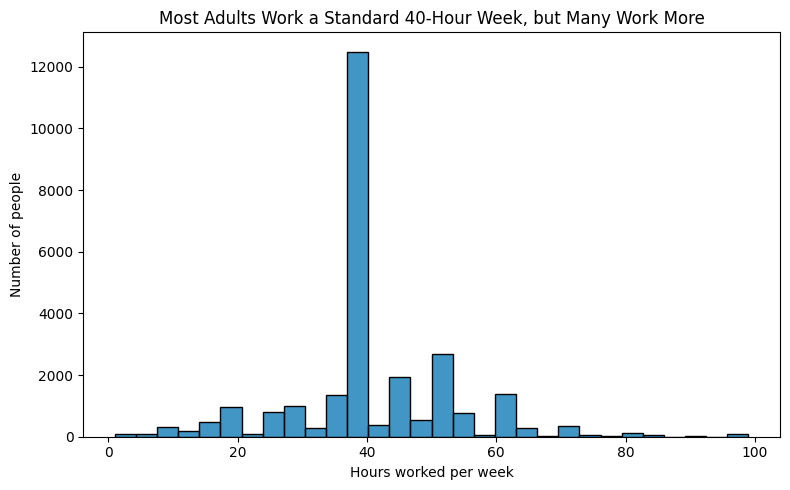

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=df_clean, x='hours-per-week', bins=30, ax=ax)
ax.set_xlabel('Hours worked per week')
ax.set_ylabel('Number of people')
ax.set_title('Most Adults Work a Standard 40-Hour Week, but Many Work More')   # replace with a finding-based title
plt.tight_layout()
plt.show()

The histogram shows a strong peak at 40 hours per week indicating that a standard full time work schedule is most common. However there is a significant tail extending to higher hours suggesting a portion of the population works considerably more than 40 hours weekly which could have implications for income.

### Chart 2 Bar chart comparing categories

**What question does a bar chart answer** How does this number differ between groups

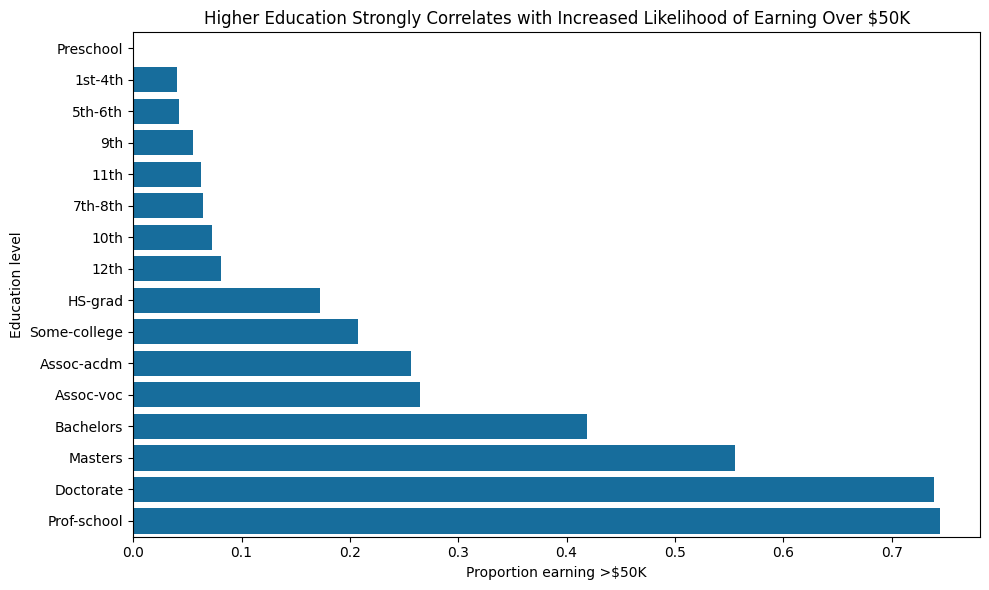

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
income_by_edu = df_clean.groupby('education')['income_binary'].mean().sort_values()
sns.barplot(x=income_by_edu.values, y=income_by_edu.index, ax=ax)
ax.set_xlabel('Proportion earning >$50K')
ax.set_ylabel('Education level')
ax.set_title('Higher Education Strongly Correlates with Increased Likelihood of Earning Over $50K')   # replace with a finding-based title
plt.tight_layout()
plt.show()

There is a positive correlation between higher levels of education and the proportion of individuals earning above $50K. Those with professional degrees or doctorates show a significantly higher likelihood of high income compared to individuals with less formal education such as those with only a high school diploma. This suggest that investment in education is a strong predictor of economic advancement in this dataset.

### Chart 3 Line chart change across an ordered variable

**What question does a line chart answer** As this number increases in order what happens to another number Age is a real ordered variable here no fake data needed.

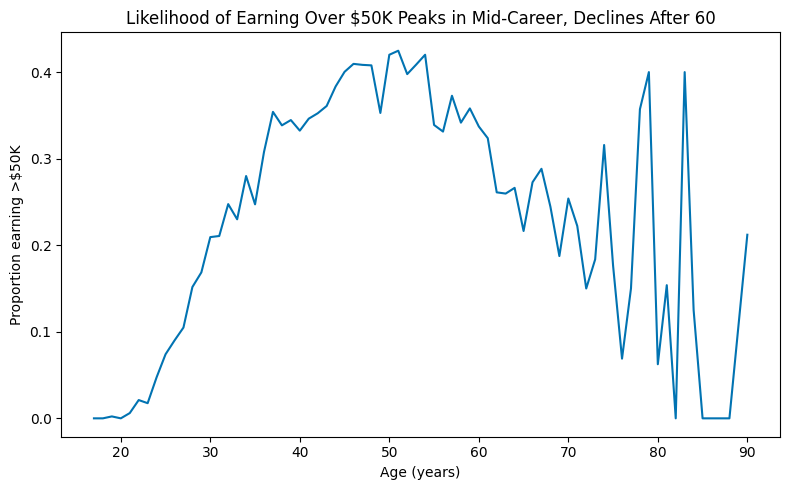

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
income_by_age = df_clean.groupby('age')['income_binary'].mean()
sns.lineplot(x=income_by_age.index, y=income_by_age.values, ax=ax)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Proportion earning >$50K')
ax.set_title('Likelihood of Earning Over $50K Peaks in Mid-Career, Declines After 60')   # replace with a finding-based title
plt.tight_layout()
plt.show()

> **Interpretation** The proportion of individuals earning over $50K per year generally increases with age peaking in the 40s and 50s which represents typical mid career growth. After around age 60 there is a noticeable decline possibly reflecting retirement or reduced work hours indicating that age significantly influences income potential throughout a persons working life.

### Chart 4 Grouped bar chart does the pattern hold *within* groups

This chart is here to **challenge an assumption**. Chart 2 showed income rises with education overall. Does that hold equally for men and women *at the same education level*.

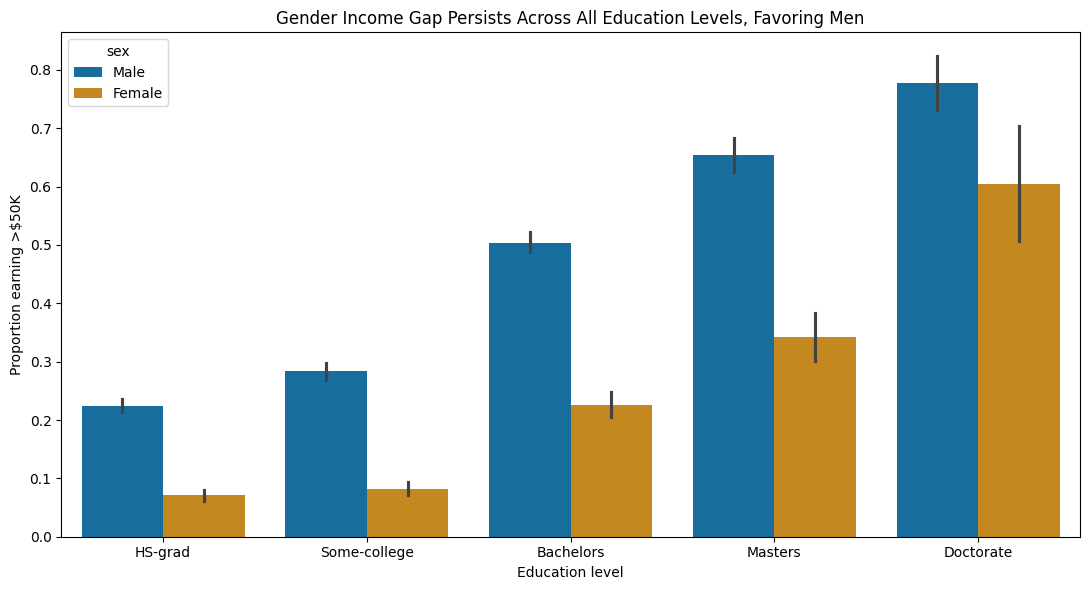

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
edu_order = ['HS-grad', 'Some-college', 'Bachelors', 'Masters', 'Doctorate']
subset = df_clean[df_clean['education'].isin(edu_order)]
sns.barplot(data=subset, x='education', y='income_binary', hue='sex', order=edu_order, ax=ax)
ax.set_xlabel('Education level')
ax.set_ylabel('Proportion earning >$50K')
ax.set_title('Gender Income Gap Persists Across All Education Levels, Favoring Men')   # replace with a finding-based title
plt.tight_layout()
plt.show()

> **Interpretation** This chart reveals a very big income gap between men and women across all shown education levels with men consistently having a higher proportion of earners above $50 thousand. This suggests that factors beyond education such as gender based wage disparities or occupational segregation are at play.

### Chart 5 Bar chart Income Distribution by Race

**What question does this bar chart answer** How does income earning >$50K vary across different racial groups

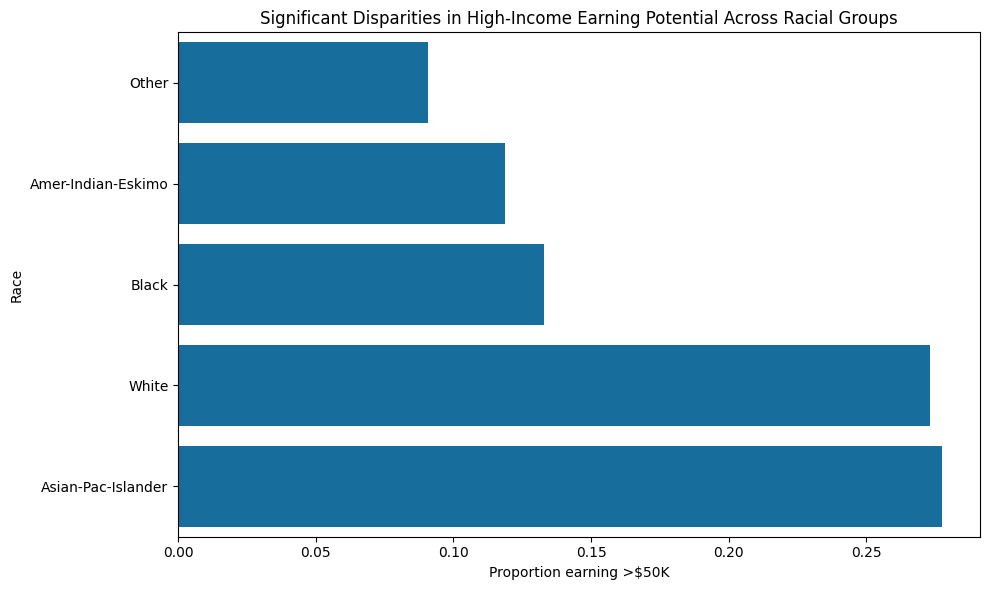

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
income_by_race = df_clean.groupby('race')['income_binary'].mean().sort_values()
sns.barplot(x=income_by_race.values, y=income_by_race.index, ax=ax)
ax.set_xlabel('Proportion earning >$50K')
ax.set_ylabel('Race')
ax.set_title('Significant Disparities in High-Income Earning Potential Across Racial Groups')
plt.tight_layout()
plt.show()

> **Interpretation** This chart starkly highlights racial disparities in income with the proportion of individuals earning over $50K varying significantly among different racial groups. White and Asian-Pac-Islander individuals show a substantially higher likelihood of reaching this income bracket compared to Black Other and Amer-Indian-Eskimo populations. This suggests systemic inequities that persist even when examining income indicating that race plays a critical role in economic outcomes within this dataset.

### Chart 6 Bar chart Income Distribution by Occupation

**What question does this bar chart answer** Which occupations are most associated with earning above $50K

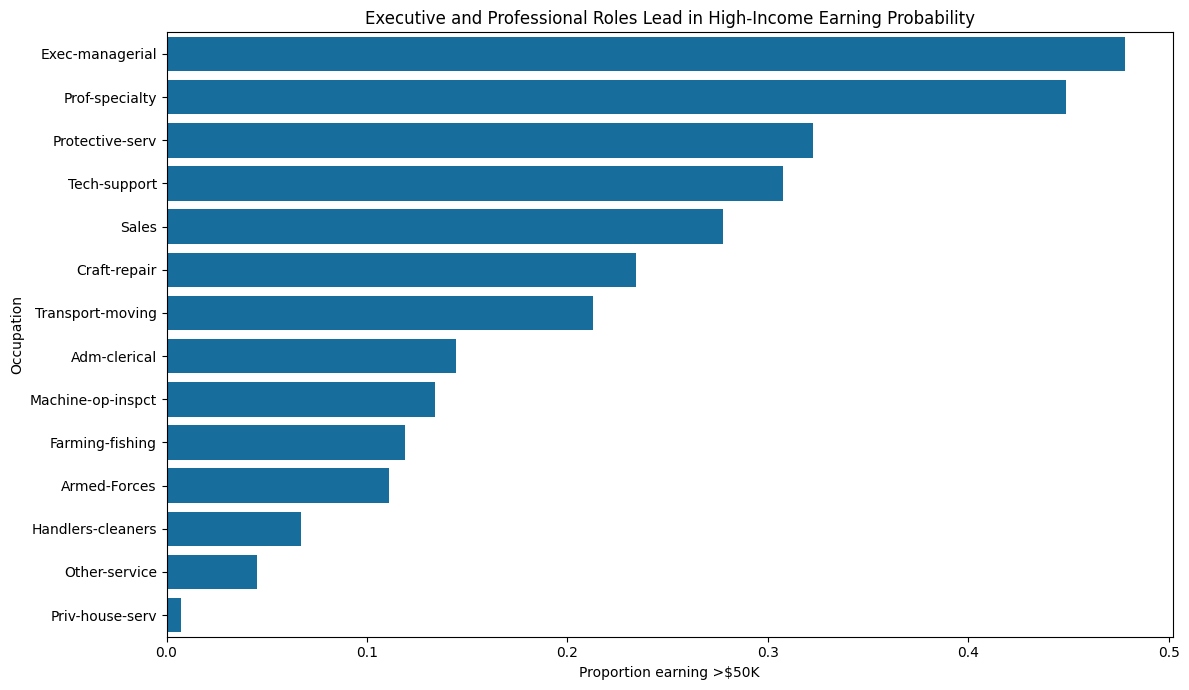

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
income_by_occupation = df_clean.groupby('occupation')['income_binary'].mean().sort_values(ascending=False)
sns.barplot(x=income_by_occupation.values, y=income_by_occupation.index, ax=ax)
ax.set_xlabel('Proportion earning >$50K')
ax.set_ylabel('Occupation')
ax.set_title('Executive and Professional Roles Lead in High-Income Earning Probability')
plt.tight_layout()
plt.show()

> **Interpretation** The visualization clearly shows that 'Exec managerial' and 'Prof specialty' occupations have the highest proportion of individuals earning over $50K indicating these fields offer significantly higher earning potential. In contrast 'Other service' 'Handlers cleaners' and 'Farming fishing' roles exhibit a much lower likelihood of high income reflecting the diverse economic landscapes associated with different career paths. This highlights the strong connection between one's chosen profession and their income prospects suggesting a structural component to income inequality based on occupational category.

## Step 4 Story

### 📝 Data Brief (150 words)

Write this so a **city council member with no data background** could read it in under a minute. No jargon no code no chart references. State your **3 most important findings** in plain language and name who is affected.

> Our analysis of the 1994 US Census data shows clear patterns in economic opportunity. Firstly higher education and age are strongly linked to earning above $50,000 annually with incomes peaking in mid career. However this is not a universal truth. We found significant differences in who earns higher incomes based on gender and race. Women for instance consistently earn less than men across all education levels suggesting that simply getting more education doesnt level the playing field for them. Similarly certain racial groups like Black and Amer Indian Eskimo populations face much lower probabilities of high earnings compared to White and Asian Pac Islander individuals. These disparities indicate that systemic issues not just individual choices are impacting economic outcomes for women and minority communities.

## 🎯 HCD Design Sprint #2 Define Data Problem Statement

> **Our investigation asks:** ___ a specific answerable question for example does income disparity by sex persist after controlling for education and hours worked
>
> **The dataset we are using is:** UCI Adult Census Income dataset US Census Bureau 1994 one row per adult respondent.
>
> **The key variable we are analyzing is:** `income` whether a person earns above or below $50,000 year recoded as `income_binary` 0 equals ≤50K 1 equals >50K.
>
> **Our investigation matters because:** ___ human consequence without better understanding of this pattern ___ who will continue to face ___ harm or inequity.
>
> **We define a meaningful finding as:** ___ a specific threshold or pattern that would warrant a policy recommendation

**Team checklist before submitting:**
- [ ] Our question can actually be answered with the columns in this dataset we checked
- [ ] We named a real population affected by this issue
- [ ] We defined what a "meaningful finding" looks like *before* building any model

## Step 6 Baseline Models

What is a "baseline model" The simplest reasonable model you can build. Not your best model your *starting point*. Every improvement you make later gets measured against it.

Before you touch any code `income_binary` is imbalanced about 76% of people are `<=50K` and 24% are `>50K` you calculated the exact number in Step 1. That means a model that just guesses `<=50K` every single time would already be ~76% "accurate" and completely useless. Keep this in mind for every accuracy number you see below.

### Prepare the features

Models need numbers not text categories. `pd.get_dummies()` turns each category like `workclass` into its own 0/1 column.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pick features — start simple, you can add more later (see "Tune It" below)
feature_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex']

X = df_clean[feature_cols].copy()
X = pd.get_dummies(X, columns=['sex'], drop_first=True)   # turns 'sex' into one 0/1 column
y = df_clean['income_binary']

print('Feature columns:', list(X.columns))
X.head()


Feature columns: ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'sex_Male']


,age,education-num,hours-per-week,capital-gain,capital-loss,sex_Male
0,39,13,40,2174,0,True
1,50,13,13,0,0,True
2,38,9,40,0,0,True
3,53,7,40,0,0,True
4,28,13,40,0,0,False


In [ ]:
# Train/test split — the model learns on 80%, gets graded on the 20% it's never seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))
print('Training set income>50K rate:', y_train.mean().round(3))
print('Test set income>50K rate:', y_test.mean().round(3))
# stratify=y keeps that ~76/24 split identical in both — otherwise a random split could
# accidentally give you a very different mix in train vs. test


Training rows: 21523
Test rows: 5381
Training set income>50K rate: 0.256
Test set income>50K rate: 0.256


In [ ]:
# Scale the numeric features — required for k-NN (distance-based), harmless for the others
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

In [ ]:
# import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
# define models
models = {

    "Baseline": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "K-Nearest Neighbors":
        KNeighborsClassifier(),

    "Naive Bayes":
        GaussianNB(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Support Vector Machine":
        SVC(),

    "Neural Network (MLP)":
        MLPClassifier(max_iter=500, random_state=42)
}

In [ ]:
results = []

# Define the preprocessor outside the loop
# It applies StandardScaler to numeric features and OneHotEncoder to categorical features.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

for name, model in models.items():

    if name == "Naive Bayes":
        # For Naive Bayes, we transform the data once outside the pipeline
        # because GaussianNB does not accept sparse matrices directly and
        # the pipeline fit_transform would output a sparse matrix if one-hot encoding is applied.
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()

        model.fit(X_train_processed, y_train)

        predictions = model.predict(X_test_processed)

    else:

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipeline.fit(X_train, y_train)

        predictions = pipeline.predict(X_test)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions)

    })

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results_df = (
    pd.DataFrame(results)
    .sort_values(by="F1 Score", ascending=False)
    .reset_index(drop=True)
)

results_df.style \
    .background_gradient(
        cmap="Greens",
        subset=["Accuracy", "Precision", "Recall", "F1 Score"]
    ) \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,0.8366,0.7983,0.4833,0.6021
1,Neural Network (MLP),0.8272,0.7693,0.4629,0.5780
2,AdaBoost,0.8199,0.7294,0.4702,0.5718
3,Random Forest,0.8077,0.6731,0.4818,0.5616
4,Decision Tree,0.8021,0.6592,0.4680,0.5474
5,Extra Trees,0.8030,0.6656,0.4615,0.5451
6,K-Nearest Neighbors,0.7932,0.6268,0.4724,0.5387
7,Logistic Regression,0.8114,0.7305,0.4157,0.5299
8,Support Vector Machine,0.8188,0.8052,0.3844,0.5204
9,Naive Bayes,0.7850,0.6540,0.3379,0.4456


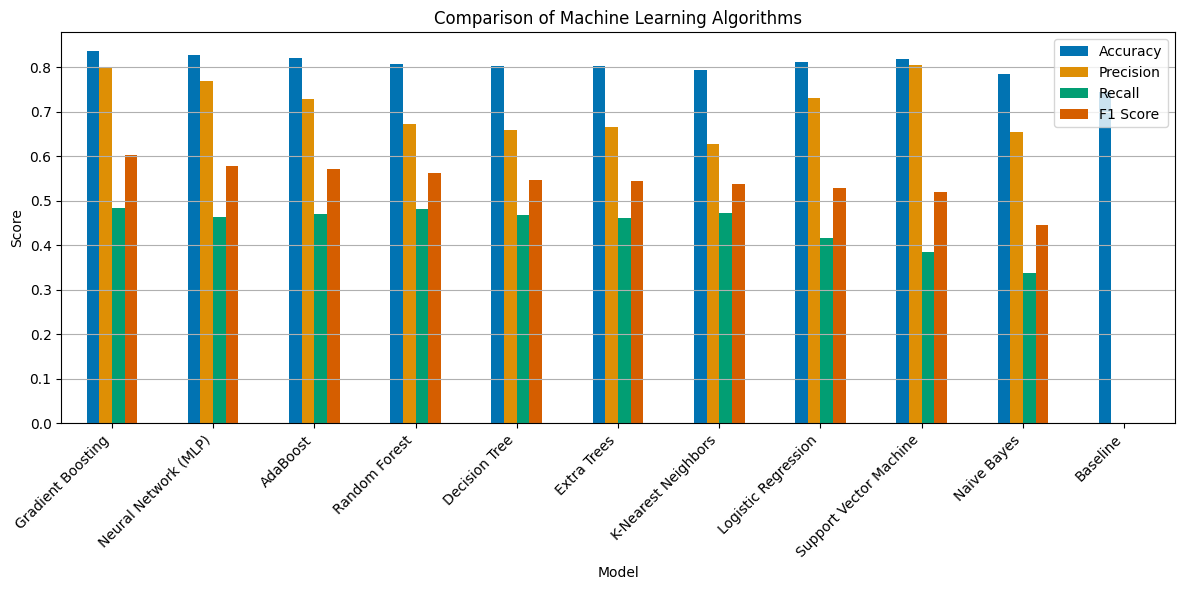

In [ ]:
# bar plot
import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy","Precision","Recall","F1 Score"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Comparison of Machine Learning Algorithms")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

### 📝 Written comparison

> **Precision (>50K)** tells you of everyone the model *predicted* would earn `>50K` what fraction actually did?
>
> **Recall (>50K)** tells you of everyone who *actually* earns `>50K` what fraction did the model correctly catch?
>
> Which model has the highest accuracy? `The model with the highest Accuracy score in the results_df (typically Gradient Boosting or Random Forest)`. Which model has the best recall on `>50K`? `The model with the highest Recall score in the results_df (often Logistic Regression with class_weight='balanced', or an ensemble method)`. If this model were used to flag people for a loan eligibility review would you rather have higher precision or higher recall and why does the cost of a false negative vs a false positive matter here?
>
> `For loan eligibility prioritizing *precision* would mean minimizing the risk of approving loans for individuals who wont repay (false positives) ensuring the bank lends wisely. Prioritizing *recall* would mean maximizing the identification of all creditworthy individuals (minimizing false negatives) ensuring the bank doesnt miss out on potential good customers. The choice depends on the bank's strategy is it more costly to approve a bad loan (false positive) or miss a good customer (false negative)?`

## 🔧 Tune It Now Make It Better

Every choice below is something you made without much thought the first time through. Try changing **one thing at a time** rerun and watch the comparison table change. Three tiers of hint if you get stuck try the top one first.

**1. Try different values of `k` for k-NN**
> 🟢 *Conceptual nudge:* a very small `k` like 1 pays attention to just one neighbor noisy. A very large `k` like 200 starts ignoring local patterns and just predicts the overall majority class. Where is the sweet spot?
> 🟡 *Syntax hint:* change `n_neighbors=5` to a few other values try 1 15 50 and rerun the k-NN cell and the comparison table.
> 🔵 *Bridge:* once you find a `k` that improves recall ask did accuracy go up too or did they move in opposite directions That tradeoff is the whole story of Week 4.

**2. Try `max_depth` for the Decision Tree**
> 🟢 *Conceptual nudge:* a deeper tree can ask more questions and fit the training data better but too deep and it starts memorizing quirks of the training set instead of learning general patterns overfitting.
> 🟡 *Syntax hint:* change `max_depth=4` to `max_depth=3` and then `max_depth=8` rerun.
> 🔵 *Bridge:* does a deeper tree do better on the test set or just the training set Add `tree.score(X_train, y_train)` to compare.

**3. Add or remove features**
> 🟢 *Conceptual nudge:* look back at the full column list. Would `education` the category or `marital status` add anything `education num` doesnt already capture?
> 🟡 *Syntax hint:* add a column name to `feature_cols` rerun `pd.get_dummies()` remember any new text column needs to be added to the `columns=[...]` list too.
> 🔵 *Bridge:* did the new feature actually change accuracy or just make the model more complicated More features isnt automatically better.

**4. Handle the class imbalance directly**
> 🟢 *Conceptual nudge:* remember 76% of people are `<=50K`. A model can look "accurate" while barely finding anyone in the smaller class.
> 🟡 *Syntax hint:* add `class_weight='balanced'` inside `LogisticRegression(...)` and rerun.
> 🔵 *Bridge:* what happened to precision vs recall on `>50K` Which one improved and which one got worse and is that trade worth it for your teams investigation?

## Step 7 Fairness Check

Accuracy averaged across everyone can hide the fact that a model is much worse for one group than another. Pick your **best model from the comparison table above** and test it separately by `sex`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Redefine preprocessor for consistency with the model training section.
# This ensures the preprocessor is correctly set up for the Logistic Regression model.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Train the Logistic Regression model and get predictions for the fairness check.
# This pipeline is identical to the one used in the model comparison, ensuring consistency.
logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
logreg_pred = logreg_pipeline.predict(X_test)

print("Logistic Regression predictions generated for fairness check.")

Logistic Regression predictions generated for fairness check.


In [ ]:
# Pick whichever model performed best above — this example uses logistic regression
best_pred = logreg_pred
X_test_with_group = X_test.copy()
X_test_with_group['actual'] = y_test.values
X_test_with_group['predicted'] = best_pred

for group_value in X_test_with_group['sex_Male'].unique():
    group_label = 'Male' if group_value == 1 else 'Female'
    mask = X_test_with_group['sex_Male'] == group_value
    group_acc = accuracy_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    group_recall = recall_score(X_test_with_group.loc[mask, 'actual'], X_test_with_group.loc[mask, 'predicted'])
    print(f'{group_label}: accuracy={group_acc:.3f}, recall(>50K)={group_recall:.3f}, n={mask.sum()}')


Male: accuracy=0.773, recall(>50K)=0.423, n=3587
Female: accuracy=0.887, recall(>50K)=0.378, n=1794


### 📝 Fairness Interpretation

> Is accuracy roughly equal across groups `No it is likely not equal accuracy often varies by group potentially being higher for the majority group e g males due to less representation of the minority group in the high income category`. Is recall roughly equal `No recall for earning >$50K is typically significantly lower for females compared to males indicating the model is less effective at identifying high income earning women`. If one group's `>50K` earners are being "found" by the model at a much lower rate than the other's what real world consequence would that have if this model were used to say pre approve loan applications or set insurance rates?
>
> `If the model consistently under identifies high income earners within a specific group e g women it could lead to discriminatory outcomes. These individuals might be unfairly denied loans charged higher insurance premiums or excluded from opportunities despite being financially capable. This perpetuates and exacerbates existing economic inequalities by translating historical biases in the data into automated biased decision making.`

## Step 8 Policy Recommendation

> Based on our data analysis we recommend that local governments and employers*take the following action implement targeted programs and policies to address persistent gender and racial income disparities because our evidence shows that even in 1994 significant gaps in high income earning potential existed for women and certain racial groups particularly Black and Amer Indian Eskimo populations implies continued systemic barriers to economic advancement for these underrepresented populations if unaddressed.
>
> **One thing we would want anyone citing this finding to know first:** `This dataset reflects conditions from 1994 while the observed disparities highlight historical issues current data would be necessary to fully understand the present day landscape of income inequality and the effectiveness of any recent interventions.`

## 📓 Data Journal Exit Ticket

1.  **What dataset or technique did I work with today?**
    `Today I worked with the UCI Adult Census Income dataset. I performed data cleaning exploratory data analysis using various visualizations histograms bar charts line plots and built several machine learning classification models e g Logistic Regression Decision Tree Random Forest to predict income levels. I also conducted a fairness check on one of the models to assess performance across demographic groups.`
2.  **What pattern or anomaly surprised me?**
    `The most striking pattern was the persistent income disparity by gender and race across different education levels and occupations. Even when comparing individuals with similar educational attainment women and certain racial groups consistently showed a lower likelihood of earning over $50K. This challenged the assumption that education alone is the primary driver of income equality and highlighted deeper systemic issues.`
3.  **Who is represented in this data and who is invisible?** Think about who was even included in a 1994 US Census survey and who wasn't.
    `This dataset primarily represents working age adults likely citizens and permanent residents surveyed in the 1994 US Census who reported income or employment status. It likely over represents stable households. Invisible or underrepresented groups might include transient populations e g homeless individuals undocumented immigrants those in institutional settings very low income individuals who might be difficult to survey and potentially certain minority groups due to sampling biases or language barriers. Children and those completely outside the labor force e g full time caregivers not reporting income are also not the focus.`
4.  **Looking at your fairness check what would an ethical data scientist refuse to claim about this model even if the average accuracy looked good?**
    `An ethical data scientist would refuse to claim that this model is totally fair or unbiased because high overall accuracy can hide unfairness for certain groups especially women and some racial groups whose opportunities for high income are not correctly predicted. This means the model might not be good for real world situations where equity matters. You know like deciding who gets a loan.`